In [1]:
import random
from sklearn.datasets import load_diabetes
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
X,y = load_diabetes(return_X_y=True)
print(X.shape)
print(y.shape)

(442, 10)
(442,)


# OLS METHOD

In [2]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
reg = LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

In [3]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [4]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.4399338661568968

# GRADIENT DISCENT

In [5]:
class MBGDRegressor:

    def __init__(self,batch_size,learning_rate=0.01,epochs=100):

        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size

    def fit(self,X_train,y_train):
        # init your coefs
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])

        for i in range(self.epochs):

            for j in range(int(X_train.shape[0]/self.batch_size)):

                idx = random.sample(range(X_train.shape[0]),self.batch_size)

                y_hat = np.dot(X_train[idx],self.coef_) + self.intercept_
                #print("Shape of y_hat",y_hat.shape)
                intercept_der = -2 * np.mean(y_train[idx] - y_hat)
                self.intercept_ = self.intercept_ - (self.lr * intercept_der)

                coef_der = -2 * np.dot((y_train[idx] - y_hat),X_train[idx])
                self.coef_ = self.coef_ - (self.lr * coef_der)

        print(self.intercept_,self.coef_)

    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [6]:
mbr = MBGDRegressor(batch_size=int(X_train.shape[0]/50),learning_rate=0.01,epochs=100)
mbr.fit(X_train,y_train)

151.64364642341764 [  28.18171324 -141.90157852  455.21482445  298.70248442  -18.52053803
  -88.06755488 -188.74108337  108.1894704   408.37819829  112.51336189]


In [7]:
y_pred = mbr.predict(X_test)
r2_score(y_test,y_pred)

0.453715099149535

#**SKLEARN GRADIENT DISCENT (SGDregressor) ACTUALLY USED THIS THROUGHOUT**

In [8]:
from sklearn.linear_model import SGDRegressor
sgd = SGDRegressor(learning_rate='constant',eta0=0.1)
batch_size = 35

for i in range(100):

    idx = random.sample(range(X_train.shape[0]),batch_size)
    sgd.partial_fit(X_train[idx],y_train[idx])

In [9]:
sgd.coef_

array([  60.68568862,  -57.69830601,  332.9962128 ,  231.83811419,
         17.73049596,  -27.26604673, -177.19599119,  139.5314758 ,
        314.71514721,  128.15478803])

In [10]:
sgd.intercept_

array([164.73230766])

In [11]:
y_pred = sgd.predict(X_test)
r2_score(y_test,y_pred)

0.40177947300331907

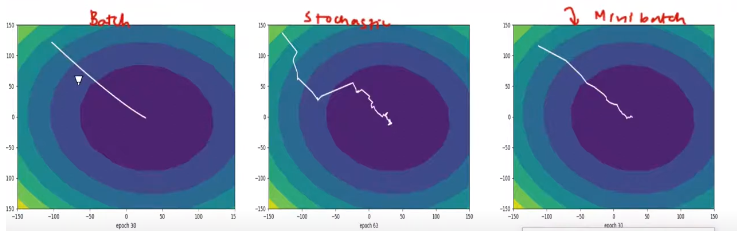